# 🎙️ Multilingual Speech Emotion Recognition
## Notebook 2: Model Training (Fusion: Whisper-tiny + eGeMAPS)

### What this notebook reads from Notebook 1:
- `processed/gemaps_features.npy` — pre-extracted, per-language normalized eGeMAPS (8548, 88)
- `processed/metadata.csv` — audio paths, emotions, language, label_idx
- `processed/train_idx.npy`, `val_idx.npy`, `test_idx.npy` — 80/10/10 split indices
- `processed/config.json` — emotion labels, sample rate, feature dims
- `processed/language_scalers.pkl` — fitted scalers (saved for inference)

### Architecture
```
Audio
  ├──→ eGeMAPS (88-dim, already extracted) → Linear(88→64) → ReLU
  │                                                                 \
  │                                                         Concat(320) → MLP → 5 emotions
  │                                                                 /
  └──→ Whisper-tiny encoder (top 2 layers fine-tuned) → MeanPool → Linear(384→256) → ReLU
```

### Training Phases
- **Phase 1** — eGeMAPS MLP only (fast, no audio loading, language-agnostic baseline)
- **Phase 2** — Whisper top-2 layers + fusion (adapts ASR features toward emotion)
- **Phase 3** — Fusion classifier only (learns optimal combination of both branches)

### How to set up
1. Click **+ Add Input** → **Notebook** tab → find your notebook 1
2. That's it — all paths are auto-detected below

In [1]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip install -q transformers librosa soundfile scikit-learn tqdm

In [2]:
# ── Cell 2: Imports ────────────────────────────────────────────────────────────
import os, json, random, warnings, shutil
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
import librosa
import joblib
from transformers import WhisperModel, WhisperFeatureExtractor
from sklearn.metrics import classification_report, confusion_matrix
from pathlib import Path
from tqdm.notebook import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Device: cuda
GPU: Tesla T4


In [3]:
# ── Cell 3: Auto-detect Notebook 1 output ─────────────────────────────────────

import os
from pathlib import Path

# ── Step 1: Print everything Kaggle mounted so we can see the real paths ───────
print("📂 Contents of /kaggle/input/:")
for item in sorted(Path('/kaggle/input').iterdir()):
    print(f"  {item}")
    for sub in sorted(item.iterdir())[:5]:   # show up to 5 children
        print(f"      {sub}")

print()

# ── Step 2: Search recursively for gemaps_features.npy ────────────────────────
print("🔍 Searching for gemaps_features.npy ...")
found = list(Path('/kaggle/input').rglob('gemaps_features.npy'))

# Also check working dir in case same session
working = Path('/kaggle/working/processed/gemaps_features.npy')
if working.exists():
    found.append(working)

if not found:
    raise RuntimeError(
        "❌  gemaps_features.npy not found anywhere.\n"
        "    Check the printout above — do you see 'processed/' in any subfolder?\n"
        "    If the folder is empty, notebook 1's output may not have been saved.\n"
        "    Try: open notebook 1 → Save Version → tick 'Save Output'."
    )

# Use the first match
PROCESSED_DIR = found[0].parent
print(f"✅  Found processed data at: {PROCESSED_DIR}")

# ── All output paths for this notebook ────────────────────────────────────────
OUTPUT_DIR = Path('/kaggle/working/models')
EXPORT_DIR = OUTPUT_DIR / 'export'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)

# ── Verify all expected files ──────────────────────────────────────────────────
required = ['gemaps_features.npy', 'metadata.csv', 'config.json',
            'train_idx.npy', 'val_idx.npy', 'test_idx.npy', 'language_scalers.pkl']
missing = [f for f in required if not (PROCESSED_DIR / f).exists()]
if missing:
    raise FileNotFoundError(f'Missing files from notebook 1: {missing}')
print('All required files present ✓')

📂 Contents of /kaggle/input/:
  /kaggle/input/datasets
      /kaggle/input/datasets/ejlok1
      /kaggle/input/datasets/senadhithimanya
      /kaggle/input/datasets/uwrfkaggler
  /kaggle/input/notebooks
      /kaggle/input/notebooks/senadhithimanya

🔍 Searching for gemaps_features.npy ...
✅  Found processed data at: /kaggle/input/notebooks/senadhithimanya/01-data-preprocessing/processed
All required files present ✓


In [4]:
# ── Cell 4: Load everything from Notebook 1 ───────────────────────────────────

# Config
with open(PROCESSED_DIR / 'config.json') as f:
    cfg = json.load(f)

EMOTION_LABELS = cfg['emotion_labels']    # ['neutral','happy','sad','angry','fear']
EMOTION_TO_IDX = cfg['emotion_to_idx']
NUM_EMOTIONS   = cfg['num_emotions']      # 5
SAMPLE_RATE    = cfg['sample_rate']       # 16000
MAX_DURATION   = cfg['max_duration']      # 6.0
GEMAPS_DIM     = cfg['gemaps_dim']        # 88
MAX_SAMPLES    = int(SAMPLE_RATE * MAX_DURATION)

print(f'Emotions ({NUM_EMOTIONS}): {EMOTION_LABELS}')
print(f'Sample rate: {SAMPLE_RATE} | Max duration: {MAX_DURATION}s')
print(f'eGeMAPS dim: {GEMAPS_DIM}')

# Pre-extracted eGeMAPS features (already normalized per-language)
gemaps_all  = np.load(PROCESSED_DIR / 'gemaps_features.npy')   # (8548, 88)
train_idx   = np.load(PROCESSED_DIR / 'train_idx.npy')
val_idx     = np.load(PROCESSED_DIR / 'val_idx.npy')
test_idx    = np.load(PROCESSED_DIR / 'test_idx.npy')
df_meta     = pd.read_csv(PROCESSED_DIR / 'metadata.csv')
scalers     = joblib.load(PROCESSED_DIR / 'language_scalers.pkl')

print(f'\neGeMAPS features: {gemaps_all.shape}')
print(f'Train: {len(train_idx)} | Val: {len(val_idx)} | Test: {len(test_idx)}')
print(f'\nLanguage distribution:')
print(df_meta['language'].value_counts())

Emotions (5): ['neutral', 'happy', 'sad', 'angry', 'fear']
Sample rate: 16000 | Max duration: 6.0s
eGeMAPS dim: 88

eGeMAPS features: (8548, 88)
Train: 6838 | Val: 855 | Test: 855

Language distribution:
language
english    6912
tamil       936
sinhala     700
Name: count, dtype: int64


In [5]:
# ── Cell 5: Fix augmented audio paths ─────────────────────────────────────────
#
# Notebook 1 saved augmented clips to /kaggle/working/processed/augmented_audio/
# In this new session they live under /kaggle/input/<slug>/processed/augmented_audio/
# This cell remaps them automatically.

AUG_AUDIO_SRC = '/kaggle/working/processed/augmented_audio'
AUG_AUDIO_DST = str(PROCESSED_DIR / 'augmented_audio')

def fix_path(path_str):
    """Remap augmented audio paths from nb1's /working/ to the mounted input path."""
    if path_str.startswith(AUG_AUDIO_SRC):
        return path_str.replace(AUG_AUDIO_SRC, AUG_AUDIO_DST)
    return path_str

df_meta['path'] = df_meta['path'].apply(fix_path)

# Verify a few paths exist
sample_paths = df_meta['path'].sample(5, random_state=42).tolist()
for p in sample_paths:
    exists = Path(p).exists()
    status = '✓' if exists else '✗  MISSING'
    print(f'  {status}  {p}')

n_missing = df_meta['path'].apply(lambda p: not Path(p).exists()).sum()
print(f'\nMissing paths: {n_missing} / {len(df_meta)}')
if n_missing > 0:
    print('⚠️  Some audio files not found.')
    print('   Make sure you added notebook 1 as an input to this notebook.')

  ✓  /kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/OAF_happy/OAF_raise_happy.wav
  ✓  /kaggle/input/notebooks/senadhithimanya/01-data-preprocessing/processed/augmented_audio/sinhala_aug/02-01-02_aug3.wav
  ✓  /kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/tess toronto emotional speech set data/TESS Toronto emotional speech set data/YAF_angry/YAF_take_angry.wav
  ✓  /kaggle/input/datasets/ejlok1/toronto-emotional-speech-set-tess/TESS Toronto emotional speech set data/YAF_angry/YAF_hire_angry.wav
  ✓  /kaggle/input/notebooks/senadhithimanya/01-data-preprocessing/processed/augmented_audio/sinhala_aug/02-02-02_aug1.wav

Missing paths: 0 / 8548


In [6]:
# ── Cell 6: Language weights for sampler ──────────────────────────────────────
#
# Your actual counts from notebook 1:
#   English:  6912 clips → would dominate without weighting
#   Tamil:     936 clips
#   Sinhala:   700 clips → needs upsampling
#
# We compute inverse-frequency weights so each language is seen proportionally.

lang_counts = df_meta.iloc[train_idx]['language'].value_counts().to_dict()
print('Train language counts:', lang_counts)

total_train = sum(lang_counts.values())
LANG_WEIGHTS = {lang: total_train / (len(lang_counts) * count)
                for lang, count in lang_counts.items()}
print('Language sampling weights:', {k: f'{v:.3f}' for k, v in LANG_WEIGHTS.items()})
# Expected: Sinhala ≈ 4x, Tamil ≈ 3x, English ≈ 0.4x

Train language counts: {'english': 5529, 'tamil': 749, 'sinhala': 560}
Language sampling weights: {'english': '0.412', 'tamil': '3.043', 'sinhala': '4.070'}


In [7]:
# ── Cell 7: Whisper feature extractor setup ────────────────────────────────────

WHISPER_DIM = 384  # whisper-tiny encoder hidden size

whisper_fe = WhisperFeatureExtractor.from_pretrained(
    'openai/whisper-tiny', sampling_rate=SAMPLE_RATE
)

def load_audio_for_whisper(path):
    """
    Load audio, trim/pad to MAX_DURATION, return Whisper log-mel (80, 3000).
    Returns zero tensor on failure.
    """
    try:
        audio, _ = librosa.load(str(path), sr=SAMPLE_RATE, mono=True)
        if len(audio) > MAX_SAMPLES:
            audio = audio[:MAX_SAMPLES]
        inp = whisper_fe(audio, sampling_rate=SAMPLE_RATE, return_tensors='pt')
        return inp.input_features[0]  # (80, 3000)
    except Exception:
        return torch.zeros(80, 3000)

# Smoke test
test_audio = df_meta.iloc[0]['path']
test_mel   = load_audio_for_whisper(test_audio)
print(f'Whisper log-mel shape: {test_mel.shape}')  # (80, 3000)

preprocessor_config.json: 0.00B [00:00, ?B/s]

Whisper log-mel shape: torch.Size([80, 3000])


In [8]:
# ── Cell 8: Dataset class ──────────────────────────────────────────────────────
#
# eGeMAPS: just indexes into the pre-loaded numpy array — instant, no I/O
# Whisper: loads audio on-the-fly (fast with num_workers)

class SERDataset(Dataset):
    def __init__(self, indices, gemaps_array, df, use_whisper=True):
        """
        indices      : numpy array of row indices into df / gemaps_array
        gemaps_array : pre-normalized (N, 88) numpy array from notebook 1
        df           : metadata dataframe (full, not pre-sliced)
        use_whisper  : if False, returns zeros for whisper — for Phase 1
        """
        self.indices      = indices
        self.gemaps_array = gemaps_array
        self.df           = df.reset_index(drop=True)
        self.use_whisper  = use_whisper

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        idx   = self.indices[i]
        row   = self.df.iloc[idx]
        label = int(row['label_idx'])
        lang  = row['language']

        # eGeMAPS — instant numpy slice
        gemaps = torch.from_numpy(
            self.gemaps_array[idx].astype(np.float32)
        )  # (88,)

        # Whisper log-mel — audio load + feature extraction
        if self.use_whisper:
            whisper = load_audio_for_whisper(row['path'])  # (80, 3000)
        else:
            whisper = torch.zeros(80, 3000)  # placeholder

        return {
            'gemaps':  gemaps,
            'whisper': whisper,
            'label':   torch.tensor(label, dtype=torch.long),
            'lang':    lang
        }


def build_sampler(indices, df):
    """Weighted sampler: up-weights Sinhala/Tamil, down-weights English."""
    df_sub = df.iloc[indices]
    class_counts = df_sub['label_idx'].value_counts().to_dict()

    weights = []
    for idx in indices:
        row = df.iloc[idx]
        lang_w  = LANG_WEIGHTS.get(row['language'], 1.0)
        class_w = 1.0 / (class_counts.get(row['label_idx'], 1) + 1e-6)
        weights.append(lang_w * class_w)

    weights = torch.DoubleTensor(weights)
    return WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)


def make_loaders(batch_size, use_whisper, num_workers=2):
    train_ds = SERDataset(train_idx, gemaps_all, df_meta, use_whisper=use_whisper)
    val_ds   = SERDataset(val_idx,   gemaps_all, df_meta, use_whisper=use_whisper)
    test_ds  = SERDataset(test_idx,  gemaps_all, df_meta, use_whisper=use_whisper)

    sampler = build_sampler(train_idx, df_meta)

    train_loader = DataLoader(train_ds, batch_size=batch_size, sampler=sampler,
                              num_workers=num_workers, pin_memory=True)
    val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True)
    return train_loader, val_loader, test_loader


print('Dataset classes ready.')

Dataset classes ready.


In [9]:
# ── Cell 9: Model definitions ──────────────────────────────────────────────────

class GeMAPS_MLP(nn.Module):
    """Phase 1: pure eGeMAPS baseline (no audio loading at all)."""
    def __init__(self, in_dim=88, hidden=128, num_classes=5, dropout=0.3):
        super().__init__()
        # Note: features are already normalized by nb1, so no BN on input
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden),
            nn.ReLU(),
            nn.BatchNorm1d(hidden),
            nn.Dropout(dropout),
            nn.Linear(hidden, hidden // 2),
            nn.ReLU(),
            nn.BatchNorm1d(hidden // 2),
            nn.Dropout(dropout),
            nn.Linear(hidden // 2, num_classes)
        )
    def forward(self, x):
        return self.net(x)


class FusionSER(nn.Module):
    """
    Phase 2+3: Whisper-tiny encoder (top 2 layers trainable) + eGeMAPS branch.
    """
    def __init__(self, num_classes=5, dropout=0.3,
                 gemaps_proj=64, whisper_proj=256, n_unfreeze=2):
        super().__init__()

        # ── Whisper encoder ────────────────────────────────────────────────────
        self.whisper_enc = WhisperModel.from_pretrained('openai/whisper-tiny').encoder

        # Freeze all
        for p in self.whisper_enc.parameters():
            p.requires_grad = False

        # Unfreeze top N layers + final layer norm
        n_layers = len(self.whisper_enc.layers)
        for layer in self.whisper_enc.layers[n_layers - n_unfreeze:]:
            for p in layer.parameters():
                p.requires_grad = True
        for p in self.whisper_enc.layer_norm.parameters():
            p.requires_grad = True

        trainable = sum(p.numel() for p in self.whisper_enc.parameters() if p.requires_grad)
        total     = sum(p.numel() for p in self.whisper_enc.parameters())
        print(f'Whisper encoder: {trainable:,} / {total:,} params trainable ({trainable/total:.1%})')

        # ── Whisper projection ─────────────────────────────────────────────────
        self.w_proj = nn.Sequential(
            nn.Linear(WHISPER_DIM, whisper_proj),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── eGeMAPS branch ─────────────────────────────────────────────────────
        # Note: features already normalized by nb1 — no BN needed here
        self.g_proj = nn.Sequential(
            nn.Linear(GEMAPS_DIM, gemaps_proj),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        # ── Fusion classifier ──────────────────────────────────────────────────
        fusion_dim = whisper_proj + gemaps_proj  # 256 + 64 = 320
        self.classifier = nn.Sequential(
            nn.Linear(fusion_dim, 128),
            nn.ReLU(),
            nn.BatchNorm1d(128),
            nn.Dropout(dropout),
            nn.Linear(128, num_classes)
        )

    def forward(self, whisper_inp, gemaps):
        # Whisper branch
        w = self.whisper_enc(whisper_inp).last_hidden_state.mean(dim=1)  # (B, 384)
        w = self.w_proj(w)                                                # (B, 256)
        # eGeMAPS branch
        g = self.g_proj(gemaps)                                           # (B, 64)
        # Fuse
        return self.classifier(torch.cat([w, g], dim=-1))                 # (B, 5)

    def set_phase(self, phase):
        """
        phase 2: train whisper top layers + whisper proj + classifier
        phase 3: freeze everything, train only classifier + gemaps proj
        """
        if phase == 2:
            # gemaps branch frozen — whisper branch + classifier trainable
            for p in self.g_proj.parameters():
                p.requires_grad = False
            for p in self.w_proj.parameters():
                p.requires_grad = True
            for p in self.classifier.parameters():
                p.requires_grad = True
        elif phase == 3:
            # Freeze everything
            for p in self.parameters():
                p.requires_grad = False
            # Unfreeze classifier + gemaps proj only
            for p in self.classifier.parameters():
                p.requires_grad = True
            for p in self.g_proj.parameters():
                p.requires_grad = True

        n_train = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f'Phase {phase}: {n_train:,} trainable params')


print('Models defined.')

Models defined.


In [10]:
# ── Cell 10: Training loop utilities ──────────────────────────────────────────

def run_epoch(model, loader, optimizer, criterion, device, train=True, mode='fusion'):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    all_preds, all_labels, all_langs = [], [], []

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch in tqdm(loader, desc='Train' if train else 'Val  ', leave=False):
            labels  = batch['label'].to(device)
            gemaps  = batch['gemaps'].to(device)
            whisper = batch['whisper'].to(device)

            if train:
                optimizer.zero_grad()

            logits = model(gemaps) if mode == 'gemaps' else model(whisper, gemaps)
            loss   = criterion(logits, labels)

            if train:
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()

            preds = logits.argmax(-1)
            total_loss += loss.item() * labels.size(0)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_langs.extend(batch['lang'])

    return total_loss / total, correct / total, all_preds, all_labels, all_langs


def per_language_acc(preds, labels, langs):
    df = pd.DataFrame({'p': preds, 'l': labels, 'lang': langs})
    for lang in ['english', 'tamil', 'sinhala']:
        sub = df[df['lang'] == lang]
        if len(sub) == 0:
            continue
        acc = (sub['p'] == sub['l']).mean()
        print(f'  {lang:<10}: {acc:.3f}  (n={len(sub)})')


def save_ckpt(model, path, meta=None):
    torch.save({'state_dict': model.state_dict(), 'meta': meta or {}}, path)
    print(f'  💾 Saved → {path}')


def load_ckpt(model, path):
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    return model


def plot_history(history, title):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4))
    a1.plot(history['tr_loss'], label='Train'); a1.plot(history['vl_loss'], label='Val')
    a1.set_title(f'{title} — Loss'); a1.set_xlabel('Epoch'); a1.legend()
    a2.plot(history['tr_acc'],  label='Train'); a2.plot(history['vl_acc'],  label='Val')
    a2.set_title(f'{title} — Accuracy'); a2.set_xlabel('Epoch'); a2.legend()
    plt.tight_layout(); plt.show()


print('Training utilities ready.')

Training utilities ready.


PHASE 1 — eGeMAPS MLP


Train:   0%|          | 0/54 [00:00<?, ?it/s]

Val  :   0%|          | 0/7 [00:00<?, ?it/s]

Ep 01/50  tr_loss=1.284 tr_acc=0.528  vl_loss=0.873 vl_acc=0.770
  💾 Saved → /kaggle/working/models/phase1_gemaps.pt


Train:   0%|          | 0/54 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/7 [00:00<?, ?it/s]

Ep 49/50  tr_loss=0.550 tr_acc=0.955  vl_loss=0.652 vl_acc=0.869


Train:   0%|          | 0/54 [00:00<?, ?it/s]

Val  :   0%|          | 0/7 [00:00<?, ?it/s]

Ep 50/50  tr_loss=0.553 tr_acc=0.952  vl_loss=0.653 vl_acc=0.870

✅ Phase 1 best val acc: 0.876

Per-language breakdown (val):
  english   : 0.907  (n=691)
  tamil     : 0.532  (n=94)
  sinhala   : 0.957  (n=70)


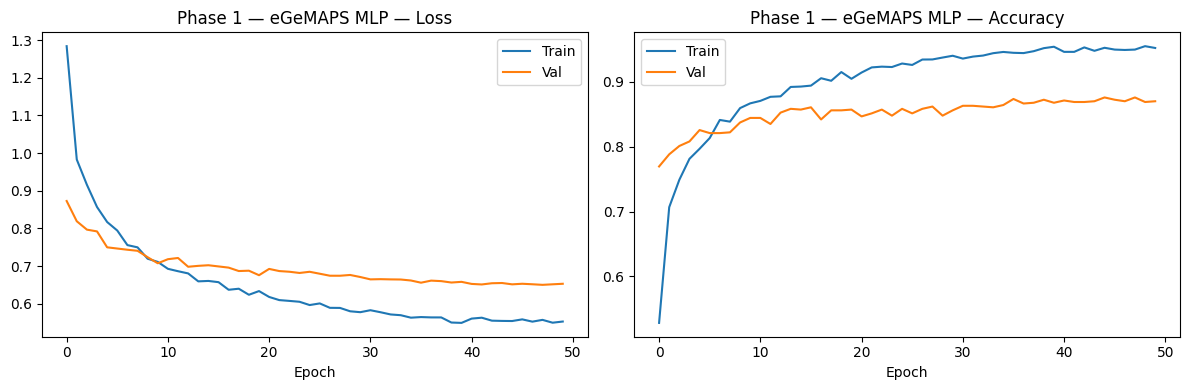

In [11]:
# ── Cell 11: PHASE 1 — eGeMAPS MLP ───────────────────────────────────────────
#
# No audio loading at all — just matrix ops on pre-extracted numpy features.
# Should train in 2-3 minutes even on CPU.

P1_EPOCHS = 50
P1_LR     = 3e-3
P1_BATCH  = 128   # large batch fine since no audio loading
P1_CKPT   = OUTPUT_DIR / 'phase1_gemaps.pt'

print('=' * 50)
print('PHASE 1 — eGeMAPS MLP')
print('=' * 50)

train_ldr1, val_ldr1, test_ldr1 = make_loaders(P1_BATCH, use_whisper=False)

mlp = GeMAPS_MLP(in_dim=GEMAPS_DIM, hidden=128, num_classes=NUM_EMOTIONS).to(DEVICE)
opt1   = AdamW(mlp.parameters(), lr=P1_LR, weight_decay=1e-3)
sched1 = CosineAnnealingLR(opt1, T_max=P1_EPOCHS)
crit   = nn.CrossEntropyLoss(label_smoothing=0.1)

best1   = 0.0
hist1   = {'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[]}

for ep in range(1, P1_EPOCHS + 1):
    tr_loss, tr_acc, *_ = run_epoch(mlp, train_ldr1, opt1, crit, DEVICE, train=True,  mode='gemaps')
    vl_loss, vl_acc, vl_preds, vl_labels, vl_langs = run_epoch(
        mlp, val_ldr1, opt1, crit, DEVICE, train=False, mode='gemaps')
    sched1.step()

    hist1['tr_loss'].append(tr_loss); hist1['vl_loss'].append(vl_loss)
    hist1['tr_acc'].append(tr_acc);   hist1['vl_acc'].append(vl_acc)

    print(f'Ep {ep:02d}/{P1_EPOCHS}  '
          f'tr_loss={tr_loss:.3f} tr_acc={tr_acc:.3f}  '
          f'vl_loss={vl_loss:.3f} vl_acc={vl_acc:.3f}')

    if vl_acc > best1:
        best1 = vl_acc
        save_ckpt(mlp, P1_CKPT, {'val_acc': vl_acc, 'epoch': ep})

print(f'\n✅ Phase 1 best val acc: {best1:.3f}')
mlp = load_ckpt(mlp, P1_CKPT)

print('\nPer-language breakdown (val):')
per_language_acc(vl_preds, vl_labels, vl_langs)
plot_history(hist1, 'Phase 1 — eGeMAPS MLP')

Val  :   0%|          | 0/7 [00:00<?, ?it/s]

              precision    recall  f1-score   support

     neutral       0.85      0.88      0.87       173
       happy       0.91      0.88      0.89       234
         sad       0.80      0.84      0.82       153
       angry       0.89      0.89      0.89       152
        fear       0.93      0.89      0.91       143

    accuracy                           0.88       855
   macro avg       0.88      0.88      0.88       855
weighted avg       0.88      0.88      0.88       855



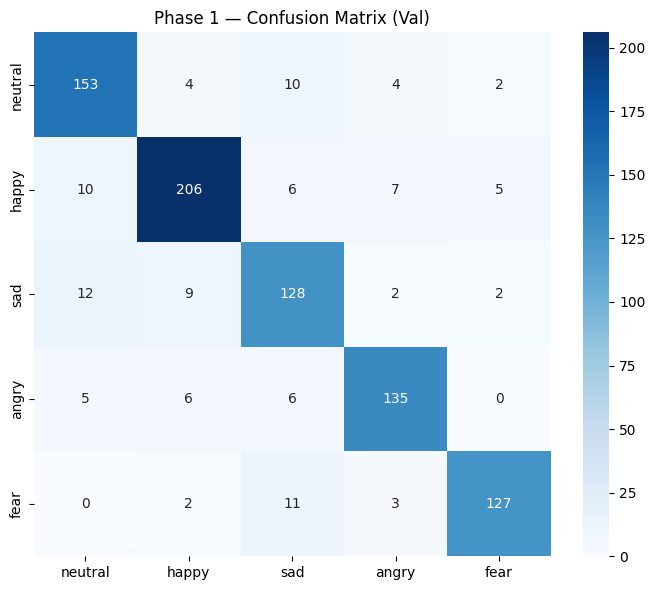

In [12]:
# ── Cell 12: Phase 1 — full classification report ─────────────────────────────

_, _, vl_preds, vl_labels, vl_langs = run_epoch(
    mlp, val_ldr1, opt1, crit, DEVICE, train=False, mode='gemaps')

print(classification_report(vl_labels, vl_preds,
                             target_names=EMOTION_LABELS, zero_division=0))

cm = confusion_matrix(vl_labels, vl_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTION_LABELS,
            yticklabels=EMOTION_LABELS, cmap='Blues', ax=ax)
ax.set_title('Phase 1 — Confusion Matrix (Val)'); plt.tight_layout(); plt.show()

PHASE 2 — Whisper fine-tune + Fusion


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/151M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/167 [00:00<?, ?it/s]

Whisper encoder: 3,548,928 / 8,208,384 params trainable (43.2%)
Phase 2: 3,689,477 trainable params


...

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

Ep 19/20  tr_loss=0.415 tr_acc=1.000  vl_loss=0.571 vl_acc=0.933


Train:   0%|          | 0/428 [00:00<?, ?it/s]

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

Ep 20/20  tr_loss=0.415 tr_acc=1.000  vl_loss=0.572 vl_acc=0.933

✅ Phase 2 best val acc: 0.936

Per-language breakdown (val):
  english   : 0.994  (n=691)
  tamil     : 0.479  (n=94)
  sinhala   : 0.943  (n=70)


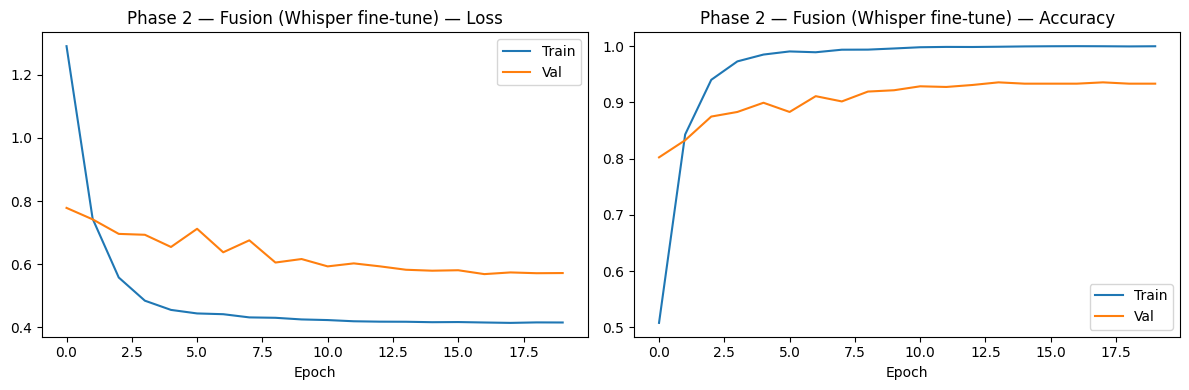

In [13]:
# ── Cell 13: PHASE 2 — Whisper top-2 layers + Fusion ─────────────────────────
#
# Whisper top 2 transformer layers are trainable.
# eGeMAPS branch frozen in this phase — Whisper learns independently first.
# Smaller batch (Whisper is heavier), lower LR (fine-tuning, not training from scratch).

P2_EPOCHS = 20
P2_LR     = 1e-4
P2_BATCH  = 16   # reduce if OOM
P2_CKPT   = OUTPUT_DIR / 'phase2_fusion.pt'

print('=' * 50)
print('PHASE 2 — Whisper fine-tune + Fusion')
print('=' * 50)

train_ldr2, val_ldr2, test_ldr2 = make_loaders(P2_BATCH, use_whisper=True)

fusion = FusionSER(num_classes=NUM_EMOTIONS).to(DEVICE)
fusion.set_phase(2)

trainable2 = [p for p in fusion.parameters() if p.requires_grad]
opt2   = AdamW(trainable2, lr=P2_LR, weight_decay=1e-4)
sched2 = CosineAnnealingLR(opt2, T_max=P2_EPOCHS)

best2 = 0.0
hist2 = {'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[]}

for ep in range(1, P2_EPOCHS + 1):
    tr_loss, tr_acc, *_ = run_epoch(
        fusion, train_ldr2, opt2, crit, DEVICE, train=True,  mode='fusion')
    vl_loss, vl_acc, vl_preds2, vl_labels2, vl_langs2 = run_epoch(
        fusion, val_ldr2,   opt2, crit, DEVICE, train=False, mode='fusion')
    sched2.step()

    hist2['tr_loss'].append(tr_loss); hist2['vl_loss'].append(vl_loss)
    hist2['tr_acc'].append(tr_acc);   hist2['vl_acc'].append(vl_acc)

    print(f'Ep {ep:02d}/{P2_EPOCHS}  '
          f'tr_loss={tr_loss:.3f} tr_acc={tr_acc:.3f}  '
          f'vl_loss={vl_loss:.3f} vl_acc={vl_acc:.3f}')

    if vl_acc > best2:
        best2 = vl_acc
        save_ckpt(fusion, P2_CKPT, {'val_acc': vl_acc, 'epoch': ep})

print(f'\n✅ Phase 2 best val acc: {best2:.3f}')
fusion = load_ckpt(fusion, P2_CKPT)
print('\nPer-language breakdown (val):')
per_language_acc(vl_preds2, vl_labels2, vl_langs2)
plot_history(hist2, 'Phase 2 — Fusion (Whisper fine-tune)')

PHASE 3 — Fusion Classifier (eGeMAPS + frozen Whisper)
Phase 3: 47,685 trainable params


Train:   0%|          | 0/428 [00:00<?, ?it/s]

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

Ep 01/15  tr_loss=0.418 tr_acc=0.999  vl_loss=0.583 vl_acc=0.937
  💾 Saved → /kaggle/working/models/phase3_final.pt


Train:   0%|          | 0/428 [00:00<?, ?it/s]

...

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

Ep 14/15  tr_loss=0.413 tr_acc=1.000  vl_loss=0.581 vl_acc=0.938


Train:   0%|          | 0/428 [00:00<?, ?it/s]

Val  :   0%|          | 0/54 [00:00<?, ?it/s]

Ep 15/15  tr_loss=0.412 tr_acc=1.000  vl_loss=0.584 vl_acc=0.937

✅ Phase 3 best val acc: 0.938

Per-language breakdown (val):
  english   : 0.991  (n=691)
  tamil     : 0.532  (n=94)
  sinhala   : 0.943  (n=70)


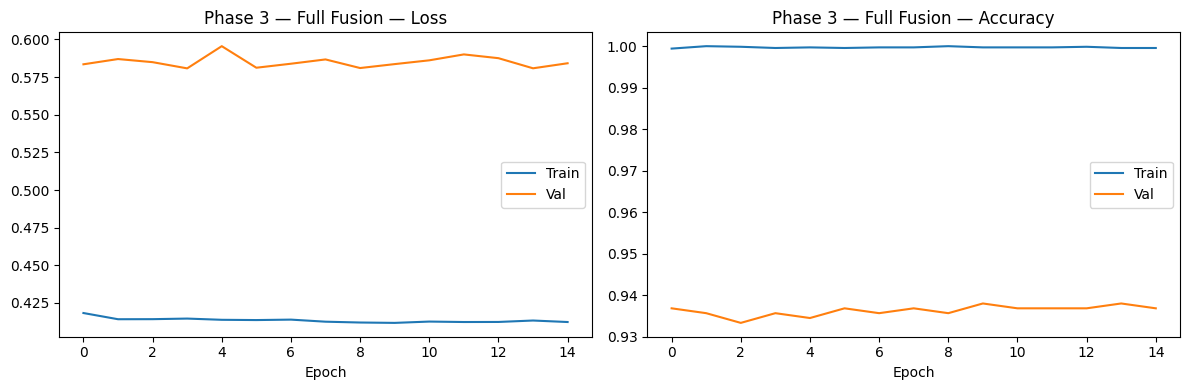

In [14]:
# ── Cell 14: PHASE 3 — Fusion Classifier Only ─────────────────────────────────
#
# Freeze Whisper entirely. Unfreeze eGeMAPS branch + final classifier.
# This trains the optimal combination of both feature streams.

P3_EPOCHS = 15
P3_LR     = 5e-4
P3_CKPT   = OUTPUT_DIR / 'phase3_final.pt'

print('=' * 50)
print('PHASE 3 — Fusion Classifier (eGeMAPS + frozen Whisper)')
print('=' * 50)

fusion.set_phase(3)

trainable3 = [p for p in fusion.parameters() if p.requires_grad]
opt3   = AdamW(trainable3, lr=P3_LR, weight_decay=1e-4)
sched3 = CosineAnnealingLR(opt3, T_max=P3_EPOCHS)

best3 = 0.0
hist3 = {'tr_loss':[], 'vl_loss':[], 'tr_acc':[], 'vl_acc':[]}

for ep in range(1, P3_EPOCHS + 1):
    tr_loss, tr_acc, *_ = run_epoch(
        fusion, train_ldr2, opt3, crit, DEVICE, train=True,  mode='fusion')
    vl_loss, vl_acc, vl_preds3, vl_labels3, vl_langs3 = run_epoch(
        fusion, val_ldr2,   opt3, crit, DEVICE, train=False, mode='fusion')
    sched3.step()

    hist3['tr_loss'].append(tr_loss); hist3['vl_loss'].append(vl_loss)
    hist3['tr_acc'].append(tr_acc);   hist3['vl_acc'].append(vl_acc)

    print(f'Ep {ep:02d}/{P3_EPOCHS}  '
          f'tr_loss={tr_loss:.3f} tr_acc={tr_acc:.3f}  '
          f'vl_loss={vl_loss:.3f} vl_acc={vl_acc:.3f}')

    if vl_acc > best3:
        best3 = vl_acc
        save_ckpt(fusion, P3_CKPT, {'val_acc': vl_acc, 'epoch': ep})

print(f'\n✅ Phase 3 best val acc: {best3:.3f}')
fusion = load_ckpt(fusion, P3_CKPT)
print('\nPer-language breakdown (val):')
per_language_acc(vl_preds3, vl_labels3, vl_langs3)
plot_history(hist3, 'Phase 3 — Full Fusion')

FINAL TEST SET EVALUATION


Val  :   0%|          | 0/54 [00:00<?, ?it/s]

Overall test accuracy: 0.937

Per-language:
  english   : 0.990  (n=692)
  tamil     : 0.516  (n=93)
  sinhala   : 0.971  (n=70)

Full classification report:
              precision    recall  f1-score   support

     neutral       0.90      0.95      0.92       172
       happy       0.93      0.94      0.94       233
         sad       0.93      0.90      0.91       154
       angry       0.96      0.91      0.94       152
        fear       0.99      0.97      0.98       144

    accuracy                           0.94       855
   macro avg       0.94      0.94      0.94       855
weighted avg       0.94      0.94      0.94       855



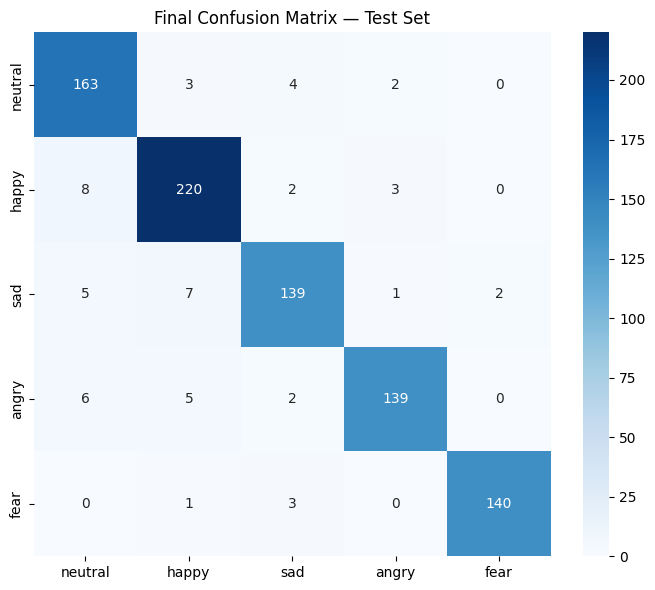

In [15]:
# ── Cell 15: Final evaluation on held-out test set ─────────────────────────────

print('=' * 50)
print('FINAL TEST SET EVALUATION')
print('=' * 50)

_, test_acc, test_preds, test_labels, test_langs = run_epoch(
    fusion, test_ldr2, opt3, crit, DEVICE, train=False, mode='fusion')

print(f'Overall test accuracy: {test_acc:.3f}\n')
print('Per-language:')
per_language_acc(test_preds, test_labels, test_langs)

print('\nFull classification report:')
print(classification_report(test_labels, test_preds,
                             target_names=EMOTION_LABELS, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_labels, test_preds)
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=EMOTION_LABELS,
            yticklabels=EMOTION_LABELS, cmap='Blues', ax=ax)
ax.set_title('Final Confusion Matrix — Test Set'); plt.tight_layout(); plt.show()

In [16]:
# ── Cell 16: Phase comparison summary ─────────────────────────────────────────

print('╔══════════════════════════════════════════╗')
print('║           PHASE COMPARISON               ║')
print('╠══════════════════════════════════════════╣')
print(f'║  Phase 1  eGeMAPS MLP         {best1:.3f}      ║')
print(f'║  Phase 2  Whisper + Fusion    {best2:.3f}      ║')
print(f'║  Phase 3  Full Fusion         {best3:.3f}      ║')
print(f'║  Test set (Phase 3)           {test_acc:.3f}      ║')
print('╚══════════════════════════════════════════╝')

╔══════════════════════════════════════════╗
║           PHASE COMPARISON               ║
╠══════════════════════════════════════════╣
║  Phase 1  eGeMAPS MLP         0.876      ║
║  Phase 2  Whisper + Fusion    0.936      ║
║  Phase 3  Full Fusion         0.938      ║
║  Test set (Phase 3)           0.937      ║
╚══════════════════════════════════════════╝


In [17]:
# ── Cell 17: Export for HF Spaces ─────────────────────────────────────────────

# ── Save model weights ────────────────────────────────────────────────────────
torch.save(fusion.state_dict(), EXPORT_DIR / 'fusion_ser.pt')
torch.save(mlp.state_dict(),    EXPORT_DIR / 'gemaps_mlp.pt')

# ── Save metadata for HF app ──────────────────────────────────────────────────
export_meta = {
    'emotion_labels':  EMOTION_LABELS,
    'emotion_to_idx':  EMOTION_TO_IDX,
    'num_emotions':    NUM_EMOTIONS,
    'sample_rate':     SAMPLE_RATE,
    'max_duration':    MAX_DURATION,
    'gemaps_dim':      GEMAPS_DIM,
    'whisper_dim':     WHISPER_DIM,
    'whisper_proj':    256,
    'gemaps_proj':     64,
    'phase1_val_acc':  best1,
    'phase2_val_acc':  best2,
    'phase3_val_acc':  best3,
    'test_acc':        test_acc,
}
with open(EXPORT_DIR / 'metadata.json', 'w') as f:
    json.dump(export_meta, f, indent=2)

# ── Copy scalers (needed for inference normalization) ─────────────────────────
shutil.copy(PROCESSED_DIR / 'language_scalers.pkl', EXPORT_DIR / 'language_scalers.pkl')
shutil.copy(PROCESSED_DIR / 'config.json',          EXPORT_DIR / 'config.json')

print('Export files:')
for f in sorted(EXPORT_DIR.iterdir()):
    size = f.stat().st_size / 1e6
    print(f'  {f.name:<30}  {size:.1f} MB')

print(f'\n✅ Everything exported to: {EXPORT_DIR}')
print('→ Run Notebook 3 to generate the HF Spaces Gradio app')

Export files:
  config.json                     0.0 MB
  fusion_ser.pt                   33.4 MB
  gemaps_mlp.pt                   0.1 MB
  language_scalers.pkl            0.0 MB
  metadata.json                   0.0 MB

✅ Everything exported to: /kaggle/working/models/export
→ Run Notebook 3 to generate the HF Spaces Gradio app
